In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, avg, count, desc, sum, dayofweek, hour, date_format
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
from pyspark.sql import SparkSession

# Khởi tạo SparkSession
spark = SparkSession.builder \
    .appName("BTL BigData - YouTube Analysis") \
    .getOrCreate()

print("✅ SparkSession đã khởi tạo.")

# Đường dẫn HDFS tới thư mục data bạn vừa put
# Dùng localhost:9000 vì Docker đã "mở" cổng đó ra máy ảo
hdfs_path = "hdfs://localhost:9000/data/cleaned_data" 

# Đọc TẤT CẢ các file CSV bên trong thư mục /data
df = spark.read.csv(
    f"{hdfs_path}/*.csv", # Dùng ký tự đại diện *
    header=True, 
    inferSchema=True,
    escape='"',       # Xử lý dấu " trong mô tả
    multiLine=True    # Xử lý mô tả có nhiều dòng
)

print("✅ Đã đọc dữ liệu từ HDFS thành công!")
df.show(5)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/10/30 22:04:51 WARN Utils: Your hostname, hung-VMware-Virtual-Platform, resolves to a loopback address: 127.0.1.1; using 192.168.248.135 instead (on interface ens33)
25/10/30 22:04:51 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/30 22:04:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ SparkSession đã khởi tạo.


25/10/30 22:05:28 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: hdfs://localhost:9000/data/cleaned_data/*.csv.
java.io.FileNotFoundException: File does not exist: hdfs://localhost:9000/data/cleaned_data/*.csv
	at org.apache.hadoop.hdfs.DistributedFileSystem$29.doCall(DistributedFileSystem.java:1832)
	at org.apache.hadoop.hdfs.DistributedFileSystem$29.doCall(DistributedFileSystem.java:1825)
	at org.apache.hadoop.fs.FileSystemLinkResolver.resolve(FileSystemLinkResolver.java:81)
	at org.apache.hadoop.hdfs.DistributedFileSystem.getFileStatus(DistributedFileSystem.java:1840)
	at org.apache.spark.sql.execution.streaming.FileStreamSink$.hasMetadata(FileStreamSink.scala:56)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:381)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveDataSource.scala:143)
	a

✅ Đã đọc dữ liệu từ HDFS thành công!


25/10/30 22:05:50 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-----------+--------------------+-------------------+--------------------+--------------------+----------+-------------------+--------------------+----------+------+--------+-------------+--------------------+-----------------+----------------+--------------------+----------------+-------------------+-------------+--------------+------------+------------+-------------+---------+---------------+----------+-------------+
|   video_id|               title|        publishedAt|           channelId|        channelTitle|categoryId|      trending_date|                tags|view_count| likes|dislikes|comment_count|      thumbnail_link|comments_disabled|ratings_disabled|         description|   category_name|       publish_time|trending_year|trending_month|trending_day|publish_year|publish_month|tag_count|engagement_rate|like_ratio|days_to_trend|
+-----------+--------------------+-------------------+--------------------+--------------------+----------+-------------------+--------------------+----


Đang tính toán xu hướng theo Tháng...
Đã tính toán xong:


+-------------+--------------+-----------+------------+-----------------+------------------+
|trending_year|trending_month|total_views|total_videos|   avg_like_ratio|    avg_engagement|
+-------------+--------------+-----------+------------+-----------------+------------------+
|         2020|             8| 2249512318|         763|95.90592885375487| 6.142857142857141|
|         2020|             9| 3212912382|        1197|96.06936601859665|5.9257560568086936|
|         2020|            10| 3521859687|        1208|96.24789649415686| 5.838301574150783|
|         2020|            11| 3183295211|         951|96.58790425531922| 5.760747368421046|
|         2020|            12| 2745247250|         943|97.03500531349627| 5.713690349946968|
|         2021|             1| 2764813460|         888|95.37178935447325| 5.002252252252252|
|         2021|             2| 2526656536|         889|96.10210407239823| 5.520472440944887|
|         2021|             3| 2852998275|         949|96.050848356309


Đang vẽ 4 biểu đồ xu hướng theo Tháng...


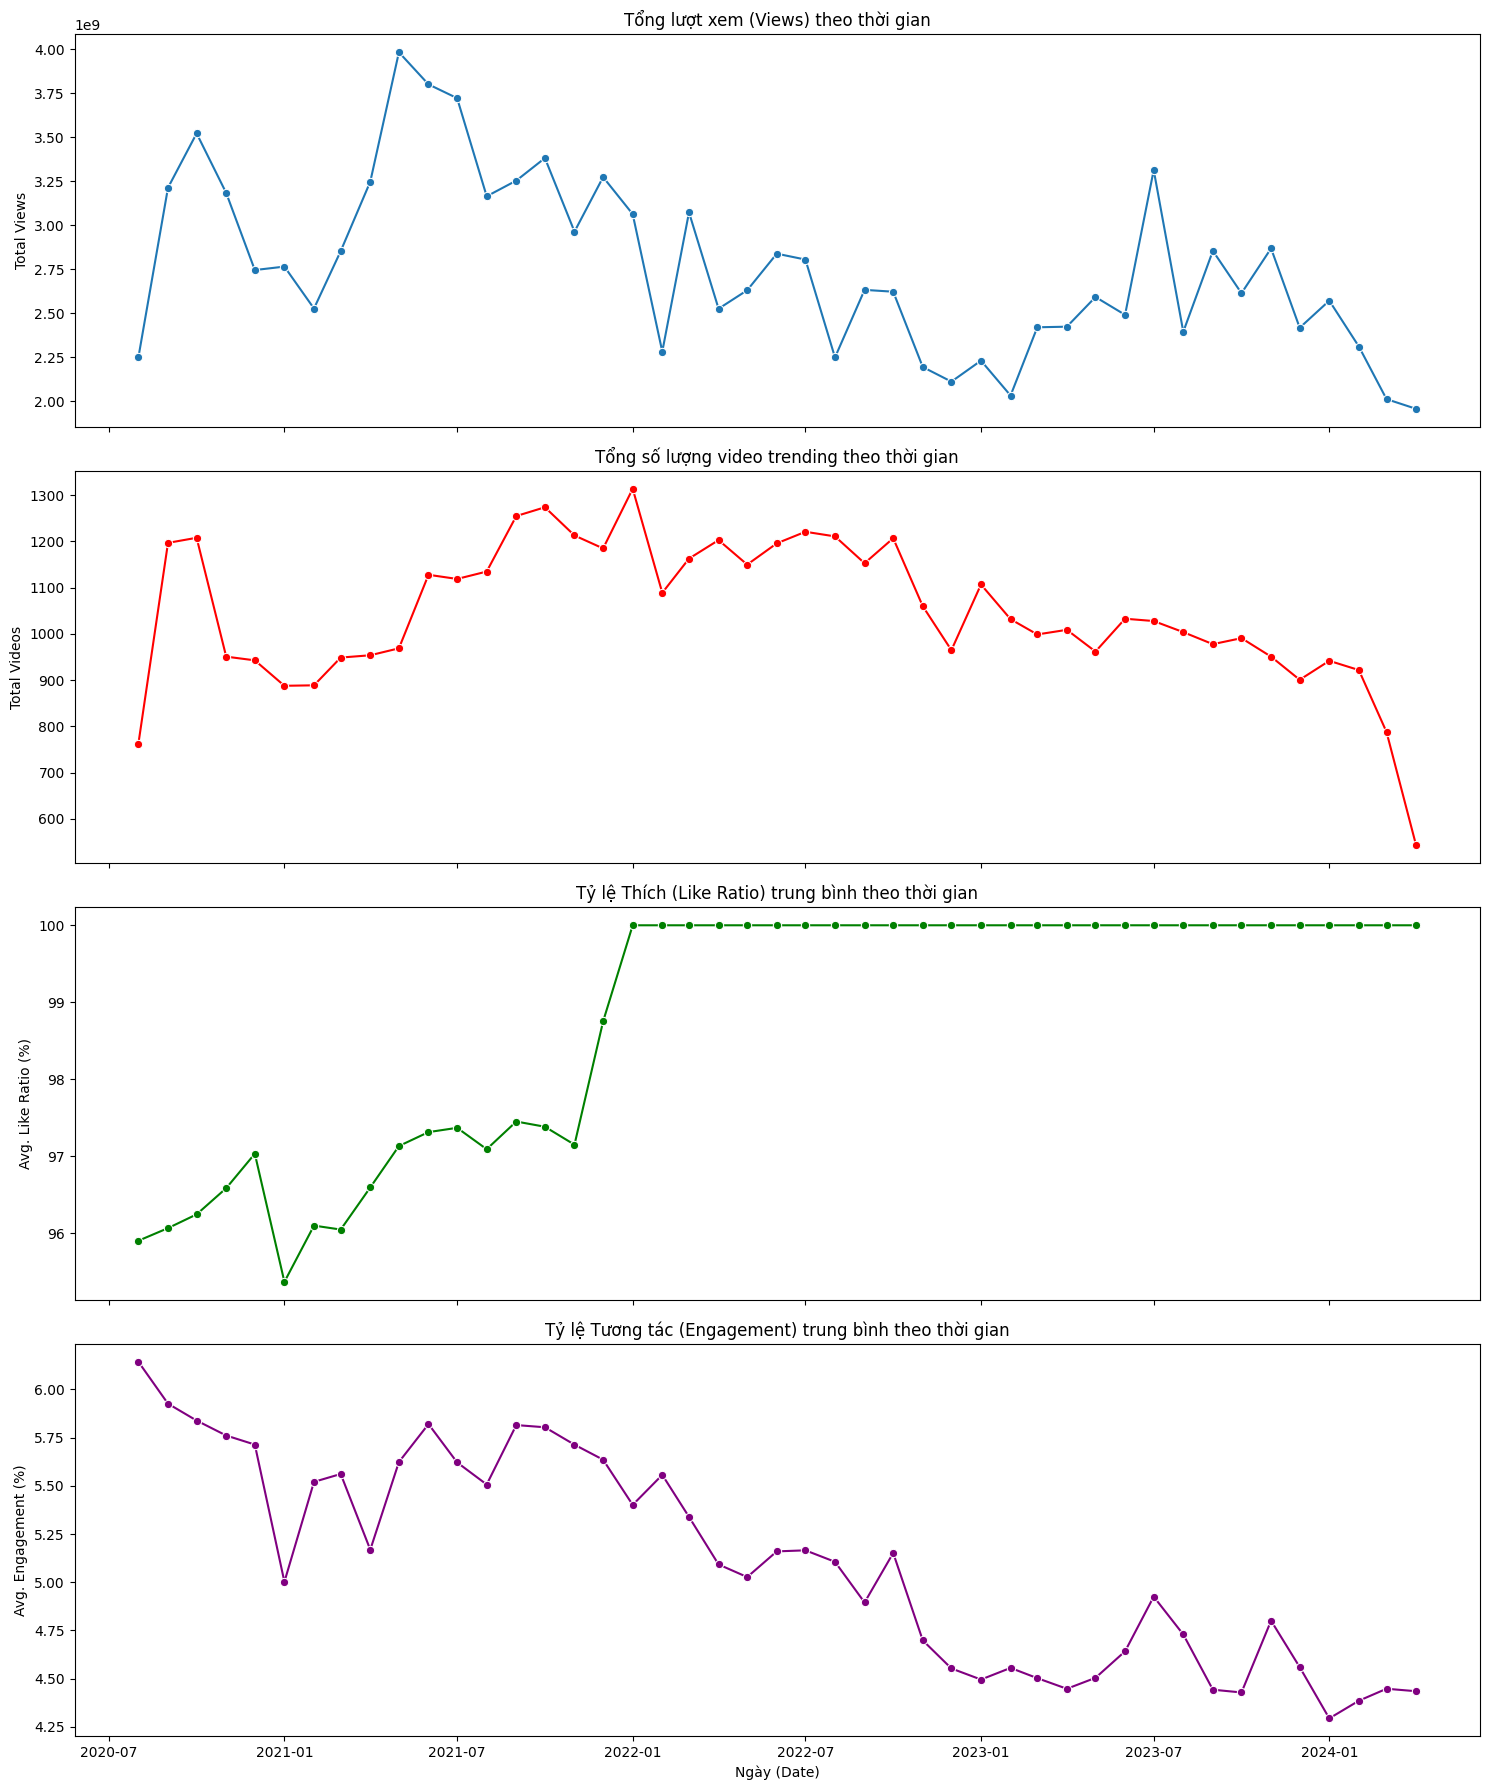

In [3]:
# --- 1. Dùng Spark để tính toán ---
print("\nĐang tính toán xu hướng theo Tháng...")
monthly_trends = df.groupBy("trending_year", "trending_month") \
    .agg(
        sum("view_count").alias("total_views"),
        count("video_id").alias("total_videos"),
        avg("like_ratio").alias("avg_like_ratio"),
        avg("engagement_rate").alias("avg_engagement")
    ) \
    .orderBy("trending_year", "trending_month")

print("Đã tính toán xong:")
monthly_trends.show()

# --- 2. Chuyển sang Pandas để vẽ ---
monthly_trends_pd = monthly_trends.toPandas()
# Tạo cột 'date' (ví dụ: '2020-08') để vẽ
monthly_trends_pd['date'] = pd.to_datetime(
    monthly_trends_pd['trending_year'].astype(str) + '-' + \
    monthly_trends_pd['trending_month'].astype(str)
)

# --- 3. Vẽ biểu đồ ---
print("\nĐang vẽ 4 biểu đồ xu hướng theo Tháng...")
fig, axes = plt.subplots(4, 1, figsize=(15, 18), sharex=True)

# Biểu đồ 1: Tổng lượt xem
sns.lineplot(data=monthly_trends_pd, x='date', y='total_views', ax=axes[0], marker='o')
axes[0].set_title('Tổng lượt xem (Views) theo thời gian')
axes[0].set_ylabel('Total Views')

# Biểu đồ 2: Tổng số lượng video
sns.lineplot(data=monthly_trends_pd, x='date', y='total_videos', ax=axes[1], marker='o', color='red')
axes[1].set_title('Tổng số lượng video trending theo thời gian')
axes[1].set_ylabel('Total Videos')

# Biểu đồ 3: Tỷ lệ thích trung bình
sns.lineplot(data=monthly_trends_pd, x='date', y='avg_like_ratio', ax=axes[2], marker='o', color='green')
axes[2].set_title('Tỷ lệ Thích (Like Ratio) trung bình theo thời gian')
axes[2].set_ylabel('Avg. Like Ratio (%)')

# Biểu đồ 4: Tỷ lệ tương tác trung bình
sns.lineplot(data=monthly_trends_pd, x='date', y='avg_engagement', ax=axes[3], marker='o', color='purple')
axes[3].set_title('Tỷ lệ Tương tác (Engagement) trung bình theo thời gian')
axes[3].set_ylabel('Avg. Engagement (%)')

plt.xlabel('Ngày (Date)')
plt.tight_layout()
plt.show()


Đang tính toán xu hướng theo Giờ & Ngày...



Đang vẽ biểu đồ xu hướng Giờ & Ngày...


/tmp/ipykernel_81687/2809521687.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dow_analysis_pd, x='trending_dow', y='count', ax=ax2, palette='Blues_d')


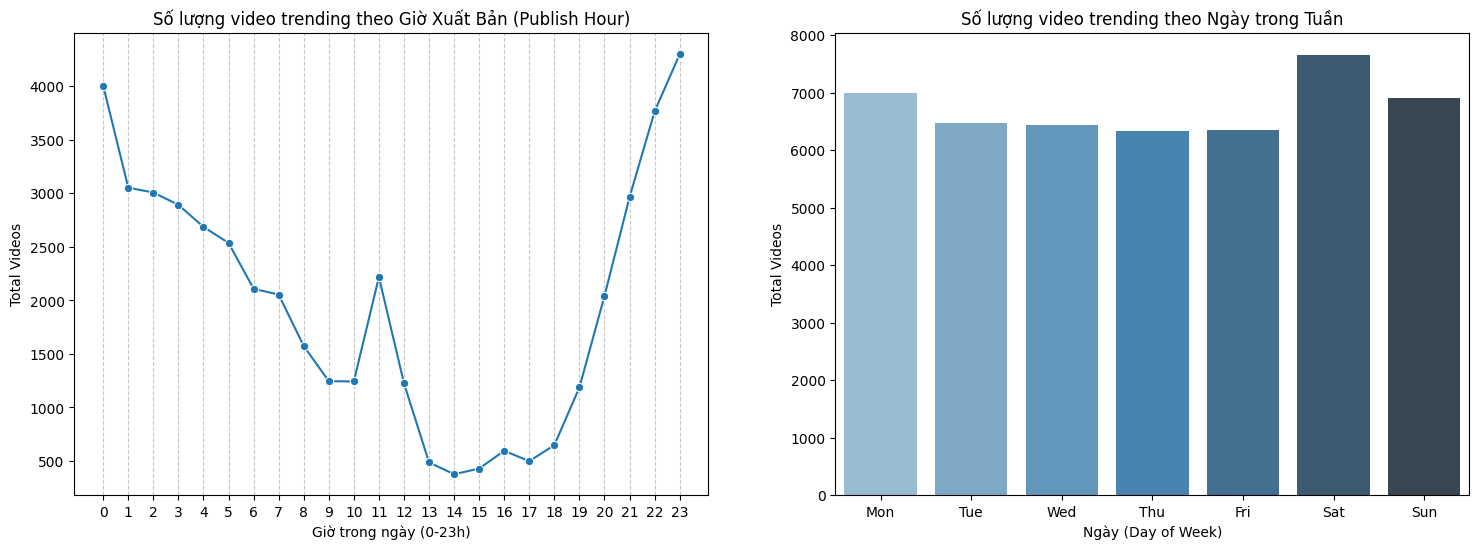

In [4]:
# --- 1. Dùng Spark để tính toán ---
print("\nĐang tính toán xu hướng theo Giờ & Ngày...")

# Thêm cột 'trending_dow' (Thứ) và 'publish_hour' (Giờ)
df_micro = df.withColumn("trending_dow", date_format(col("trending_date"), "E")) \
             .withColumn("publish_hour", hour(col("publish_time")))

# Tính toán theo Giờ
hourly_analysis = df_micro.groupBy("publish_hour") \
    .count().alias("total_videos") \
    .orderBy("publish_hour")

# Tính toán theo Thứ
dow_analysis = df_micro.groupBy("trending_dow") \
    .count().alias("total_videos")

# --- 2. Chuyển sang Pandas để vẽ ---
hourly_analysis_pd = hourly_analysis.toPandas()
dow_analysis_pd = dow_analysis.toPandas()

# Sắp xếp các ngày theo đúng thứ tự (Mon -> Sun)
days_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_analysis_pd['trending_dow'] = pd.Categorical(
    dow_analysis_pd['trending_dow'], categories=days_order, ordered=True
)
dow_analysis_pd = dow_analysis_pd.sort_values('trending_dow')

# --- 3. Vẽ biểu đồ ---
print("\nĐang vẽ biểu đồ xu hướng Giờ & Ngày...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6)) # 1 hàng, 2 cột

# Biểu đồ 1: Theo Giờ Xuất Bản
sns.lineplot(data=hourly_analysis_pd, x='publish_hour', y='count', marker='o', ax=ax1)
ax1.set_title('Số lượng video trending theo Giờ Xuất Bản (Publish Hour)')
ax1.set_xlabel('Giờ trong ngày (0-23h)')
ax1.set_ylabel('Total Videos')
ax1.grid(axis='x', linestyle='--', alpha=0.7)
ax1.set_xticks(range(0, 24))

# Biểu đồ 2: Theo Ngày Trending
sns.barplot(data=dow_analysis_pd, x='trending_dow', y='count', ax=ax2, palette='Blues_d')
ax2.set_title('Số lượng video trending theo Ngày trong Tuần')
ax2.set_xlabel('Ngày (Day of Week)')
ax2.set_ylabel('Total Videos')

plt.show()


Đang tính toán xu hướng Thể loại theo Thời gian...


Đã tính toán xong:


+--------------+--------------------+-----+
|trending_month|       category_name|count|
+--------------+--------------------+-----+
|             1|      Pets & Animals|   25|
|             1|     Travel & Events|   41|
|             1|    Autos & Vehicles|   90|
|             1|Science & Technology|  116|
|             1|           Education|  116|
|             1|       Howto & Style|  136|
|             1|    Film & Animation|  158|
|             1|              Comedy|  215|
|             1|     News & Politics|  232|
|             1|      People & Blogs|  412|
|             1|               Music|  503|
|             1|              Sports|  608|
|             1|              Gaming|  723|
|             1|       Entertainment|  876|
|             2|      Pets & Animals|   16|
|             2|     Travel & Events|   28|
|             2|           Education|   91|
|             2|       Howto & Style|  105|
|             2|    Autos & Vehicles|  113|
|             2|Science & Techno


Đang vẽ biểu đồ Heatmap Thể loại theo Tháng...


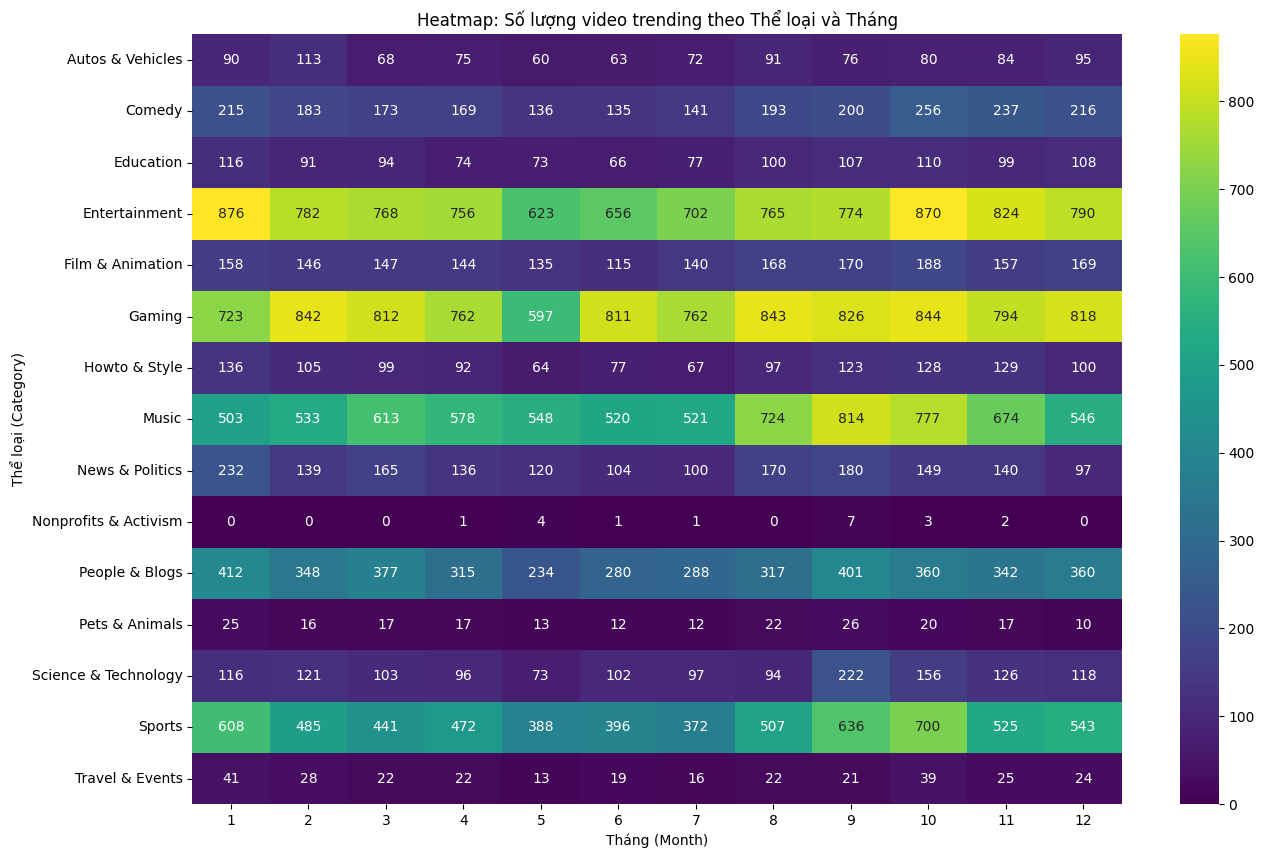

In [ ]:
# --- 1. Dùng Spark để tính toán ---
print("\nĐang tính toán xu hướng Thể loại theo Thời gian...")

# Nhóm theo cả tháng và thể loại
category_time_analysis = df.groupBy("trending_month", "category_name") \
    .count() \
    .orderBy("trending_month", "count")

print("Đã tính toán xong:")
category_time_analysis.show()

# --- 2. Chuyển sang Pandas & Pivot để vẽ Heatmap ---
category_time_pd = category_time_analysis.toPandas()

# Pivot: Biến bảng 'dài' thành bảng 'rộng'
# Hàng là Category, Cột là Tháng, Giá trị là 'count'
category_pivot = category_time_pd.pivot_table(
    index='category_name', 
    columns='trending_month', 
    values='count'
).fillna(0) # Lấp đầy các tháng không có video = 0

# --- 3. Vẽ biểu đồ (Heatmap) ---
print("\nĐang vẽ biểu đồ Heatmap Thể loại theo Tháng...")
plt.figure(figsize=(15, 10))
sns.heatmap(
    category_pivot, 
    annot=True,     # Hiển thị con số
    fmt=".0f",      # Định dạng số nguyên
    cmap="viridis"  # Dải màu
)
plt.title('Heatmap: Số lượng video trending theo Thể loại theo Tháng')
plt.xlabel('Tháng (Month)')
plt.ylabel('Thể loại (Category)')
plt.show()


Đang tính toán Ma trận Tương quan...


25/10/30 22:10:26 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Ma trận tương quan:
                 view_count     likes  dislikes  comment_count  \
view_count         1.000000  0.851379  0.440475       0.544162   
likes              0.851379  1.000000  0.466686       0.685721   
dislikes           0.440475  0.466686  1.000000       0.466503   
comment_count      0.544162  0.685721  0.466503       1.000000   
engagement_rate   -0.023525  0.210706  0.045081       0.101609   
like_ratio        -0.007738  0.022900 -0.226568      -0.007493   
days_to_trend      0.343490  0.247010  0.080923       0.093785   

                 engagement_rate  like_ratio  days_to_trend  
view_count             -0.023525   -0.007738       0.343490  
likes                   0.210706    0.022900       0.247010  
dislikes                0.045081   -0.226568       0.080923  
comment_count           0.101609   -0.007493       0.093785  
engagement_rate         1.000000    0.106521      -0.072895  
like_ratio              0.106521    1.000000       0.002964  
days_to_trend    

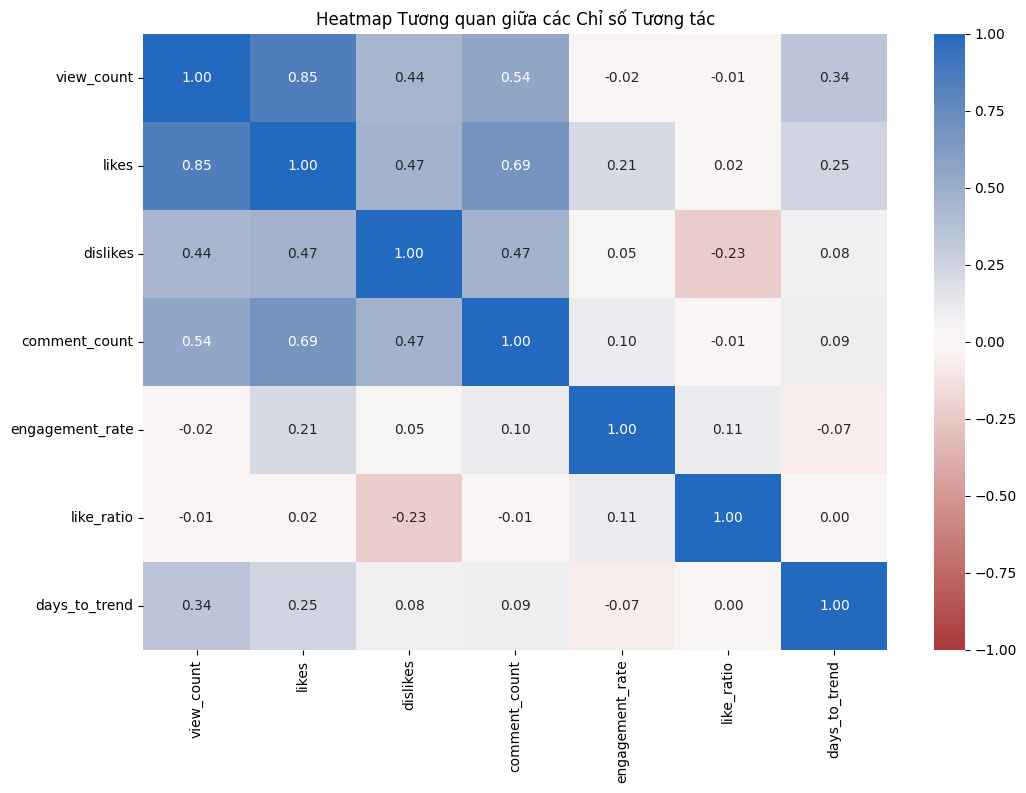

In [7]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd # Đảm bảo bạn đã import pandas

# (Các import khác như plt, sns...)

# --- 1. Phân tích Tương quan (Tương thích với Spark 3.2) ---
print("\nĐang tính toán Ma trận Tương quan...")

interaction_cols = ['view_count', 'likes', 'dislikes', 'comment_count', 'engagement_rate', 'like_ratio', 'days_to_trend']

# BƯỚC 1: Chuyển các cột số thành một cột vector duy nhất
# (Đây là yêu cầu bắt buộc của hàm Correlation)
assembler = VectorAssembler(
    inputCols=interaction_cols,
    outputCol="features",
    handleInvalid="skip" # Bỏ qua các dòng có giá trị NULL
)
df_features = assembler.transform(df).select("features")

# BƯỚC 2: Tính toán ma trận tương quan Pearson
# Lệnh .head() sẽ thực thi và trả về kết quả
corr_matrix_spark = Correlation.corr(df_features, "features").head()

# BƯỚC 3: Trích xuất ma trận (kết quả nằm ở chỉ số 0)
# Kết quả là một ma trận dày (DenseMatrix) của MLlib
corr_matrix = corr_matrix_spark[0] 

# Chuyển ma trận MLlib sang Numpy array, rồi sang Pandas DataFrame
corr_pd = pd.DataFrame(
    corr_matrix.toArray(), 
    columns=interaction_cols, 
    index=interaction_cols
)

print("Ma trận tương quan:")
print(corr_pd)

# --- 2. Vẽ biểu đồ Heatmap Tương quan ---
# (Phần code này của bạn không cần thay đổi)
print("\nĐang vẽ biểu đồ Heatmap Tương quan...")
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_pd, 
    annot=True,     # Hiển thị số
    fmt=".2f",      # 2 chữ số thập phân
    cmap="vlag_r",  # Dải màu (Đỏ -> Trắng -> Xanh)
    vmin=-1, vmax=1
)
plt.title('Heatmap Tương quan giữa các Chỉ số Tương tác')
plt.show()